Описание проекта:

Я работаю в IT-компании, которая выполняет на заказ проекты по машинному обучению. Ко мне обратился фермер, владелец молочного хозяйства «Вольный луг». Он хочет купить бурёнок, чтобы расширить поголовье стада коров. Для этого он заключил выгодный контракт с ассоциацией пастбищ «ЭкоФерма».

Условия позволяют фермеру очень тщательно отобрать коров. Он определяет качество молока по строгой методике, и при этом ему нужно выполнять свой план развития молочного хозяйства. Фермер хочет, чтобы каждая бурёнка давала не менее 6000 килограммов молока в год, а её надой был вкусным — строго по его критериям, ничуть не хуже. А продавцы и технологи так и норовят приукрасить своих коровок!

Поэтому он просит меня разработать модель машинного обучения, которая поможет ему управлять рисками и принимать объективное решение о покупке. «ЭкоФерма» готова предоставить подробные данные о своих коровах. Мне нужно создать две прогнозные модели для отбора бурёнок в поголовье:

Первая будет прогнозировать возможный удой коровы (целевой признак Удой);

Вторая — рассчитывать вероятность получить вкусное молоко от коровы (целевой признак Вкус молока).

С помощью модели нужно отобрать коров по двум критериям:

средний удой за год — не менее 6000 килограммов;

молоко должно быть вкусным.

План выполнения проекта:

    Шаг 1. Загружу и изучу данные. Мне предоставлены три датафрейма с нужной информацией. Я их изучу и проверю их оформление.

    Шаг 2. Предобработка данных.  
Проверю данные на наличие пропусков и дубликатов. Проверю корректность типов данных для каждого признака и устраняю все проблемы с данными.

    Шаг 3. Исследовательский анализ данных.  
Проведя статистический анализ всех признаков, я построю наглядные графики для каждого из них, чтобы сделать выводы о данных: есть ли выбросы, необычное распределение количественных признаков и т.д. Возможно, дам советы по улучшению качества данных.

    Шаг 4. Проведу корреляционный анализ признаков в датасете ferma_main.csv.  
В ходе изучения взаимосвязи между признаками рассчитаю коэффициенты корреляции между всеми признаками.  
А именно, построю диаграммы рассеяния (scatterplot) для признака "Удой, кг" и всех количественных признаков с учётом значения категориальных признаков, с выводами о их взаимосвязи с целевым и входными признаками. Есть ли нелинейные связи? Нужно ли вводить в модель дополнительные признаки, чтобы это учесть? Наблюдается ли мультиколлинеарность между входными признаками?

    Шаг 5. Задача регрессии.  
Обучу три модели простой линейной регрессии.  
Для этого я подготовлю данные из датасета ferma_main.csv и обучу на них первую модель LinearRegression, используя в качестве целевого признака "Удой, кг". Таким образом, отобрав признаки, которые подходят для модели линейной регрессии, я смогу аргументировать свой выбор.  
После обучения модели я смогу сделать выводы об анализе остатков и нужде в дополнительных исследованиях. Затем обучу вторую и третью модели LinearRegression, сопоставлю их R² и остатки, оценю качество каждой модели по трём метрикам: MSE, MAE, RMSE. Выбрав лучшую модель, получу прогноз удоя коров.

    Шаг 6. Задача классификации.  
Подготовлю данные из датасета ferma_main.csv и обучу на них модель LogisticRegression, используя в качестве целевого признака "Вкус молока".
Во время построения модели объясню, какая ошибка критичнее всего при покупке коров: первого или второго рода. Сведу критическую ошибку к нулю и оформлю выводы.  
С помощью обученной модели спрогнозирую вкус молока коров, которых фермер хочет купить.

    Шаг 7. Сделаю итоговые выводы.  
Добавлю прогнозы вкуса молока и удоя коров «ЭкоФермы» в датафрейм с коровами, покупку которых рассматривает фермер.  
Как только я отберу коров с прогнозируемым удоем более 6000 килограммов в год и вкусным молоком, я опишу результаты работы моделей для фермера. Укажу, сколько коров он может купить из стада на продажу с минимальным риском для себя, обосную это. Сделаю выводы о моделях линейной и логистической регрессии.

В общем, я предоставлю фермеру, владельцу молочного хозяйства «Вольный луг», итоговый отчет обо всем вышеперечисленном и подведу финальный итог.

## Загрузка данных

Импортирую нужные мне библиотеки. На этом этапе я конкретно не знаю, какие именно мне понадобятся, но я буду дополнять этот этап по мере продвижения по плану.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np
import scipy.stats as st #для доверительного интервала

from sklearn.preprocessing import (OneHotEncoder, 
                                   StandardScaler)

from sklearn.model_selection import train_test_split

from sklearn.linear_model import (LogisticRegression, 
                                  LinearRegression)

from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error, #без неё не получается работать с MSE, MAE, RMSE
                             accuracy_score, 
                             confusion_matrix, 
                             precision_score,
                             recall_score, 
                             r2_score)





В этих трех датафремах столбцы разделялись ';'. Я заменю это на ',' для дальнейшей работы с данными.

In [2]:
cow_buy = pd.read_csv('/datasets/cow_buy.csv', sep=';', decimal=',')
ferma_main = pd.read_csv('/datasets/ferma_main.csv', sep=';', decimal=',')
ferma_dad = pd.read_csv('/datasets/ferma_dad.csv', sep=';', decimal=',')

In [3]:
print(cow_buy.info())
cow_buy.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Порода                   20 non-null     object 
 1   Тип пастбища             20 non-null     object 
 2   порода папы_быка         20 non-null     object 
 3   Имя_папы                 20 non-null     object 
 4   Текущая_жирность,%       20 non-null     float64
 5   Текущий_уровень_белок,%  20 non-null     float64
 6   Возраст                  20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB
None


,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет


In [4]:
print(ferma_main.info())
ferma_main.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     634 non-null    int64  
 1   Удой, кг                               634 non-null    int64  
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    float64
 3   Сырой протеин, г                       634 non-null    int64  
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    float64
 5   Порода                                 634 non-null    object 
 6   Тип пастбища                           634 non-null    object 
 7   порода папы_быка                       634 non-null    object 
 8   Жирность,%                             634 non-null    float64
 9   Белок,%                                634 non-null    float64
 10  Вкус молока                            634 non-null    object 
 11  Возрас

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.073,вкусно,менее_2_лет


In [5]:
print(ferma_dad.info())
ferma_dad.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB
None


,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


Промежуточный вывод.
Изучив данные, я определил, соответствуют ли они описанию задачи и изученным в прошлых спринтах стандартам оформления данных. 

В них есть необходимая информация.

Типы данных в датафрейме менять не нужно. Названия столбцов надо привести к правильному регистру. 

При рассмотрении столбца СПО (Сахаро-протеиновое соотношение), я решил что из отношения сахара к протеину в корме коровы, можно извлечь новый тип данных. А именно я из столбцов 'Сырой протеин' и 'СПО' создам новый столбец "cахар"

Для начала переименую названия столбцов

In [6]:
cow_buy.rename(columns={'Порода': 'порода',
                        'Тип пастбища': 'тип_пастбища', 
                        'порода папы_быка': 'порода_папы_быка',
                        'Имя_папы': 'имя_папы', 
                        'Текущая_жирность,%': 'текущая_жирность', 
                        'Текущий_уровень_белок,%': 'текущий_белок', 
                        'Возраст': 'возраст'}, inplace = True)
cow_buy.columns.tolist()

['порода',
 'тип_пастбища',
 'порода_папы_быка',
 'имя_папы',
 'текущая_жирность',
 'текущий_белок',
 'возраст']

In [7]:
ferma_main.rename(columns={
    'Удой, кг': 'удой',
    'ЭКЕ (Энергетическая кормовая единица)': 'эке',
    'Сырой протеин, г': 'сырой_протеин',
    'СПО (Сахаро-протеиновое соотношение)': 'спо',
    'Порода': 'порода',
    'Тип пастбища': 'тип_пастбища',
    'порода папы_быка': 'порода_папы_быка',
    'Жирность,%': 'жирность',
    'Белок,%': 'белок',
    'Вкус молока': 'вкус_молока',
    'Возраст': 'возраст',
}, inplace=True)
ferma_main.columns.tolist()

['id',
 'удой',
 'эке',
 'сырой_протеин',
 'спо',
 'порода',
 'тип_пастбища',
 'порода_папы_быка',
 'жирность',
 'белок',
 'вкус_молока',
 'возраст']

In [8]:
ferma_dad.rename(columns={'Имя Папы': 'имя_папы'
                         }, inplace=True)
ferma_dad.columns.tolist()

['id', 'имя_папы']

Добавляю столбец "cахар"

In [9]:
ferma_main['сахар'] = ferma_main['сырой_протеин'] * ferma_main['спо']
display(ferma_main.head())
display(ferma_main.info())

,id,удой,эке,сырой_протеин,спо,порода,тип_пастбища,порода_папы_быка,жирность,белок,вкус_молока,возраст,сахар
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет,1551.270
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.079,вкусно,менее_2_лет,1902.820
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет,1640.790
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет,1780.620
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.073,вкусно,менее_2_лет,1482.375


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                634 non-null    int64  
 1   удой              634 non-null    int64  
 2   эке               634 non-null    float64
 3   сырой_протеин     634 non-null    int64  
 4   спо               634 non-null    float64
 5   порода            634 non-null    object 
 6   тип_пастбища      634 non-null    object 
 7   порода_папы_быка  634 non-null    object 
 8   жирность          634 non-null    float64
 9   белок             634 non-null    float64
 10  вкус_молока       634 non-null    object 
 11  возраст           634 non-null    object 
 12  сахар             634 non-null    float64
dtypes: float64(5), int64(3), object(5)
memory usage: 64.5+ KB


None

Промежуточные выводы. Данные загружены без проблем.

Добавлен новый столбец:
Сахар -  содержание сахара в корме (в граммах).

##  Предобработка данных

Проверю данные на наличие пропусков и дубликатов.

In [10]:
print(cow_buy.duplicated().sum())
cow_buy.isna().sum()

4


порода              0
тип_пастбища        0
порода_папы_быка    0
имя_папы            0
текущая_жирность    0
текущий_белок       0
возраст             0
dtype: int64

In [11]:
print(ferma_main.duplicated().sum())
ferma_main.isna().sum()

5


id                  0
удой                0
эке                 0
сырой_протеин       0
спо                 0
порода              0
тип_пастбища        0
порода_папы_быка    0
жирность            0
белок               0
вкус_молока         0
возраст             0
сахар               0
dtype: int64

In [12]:
print(ferma_dad.duplicated().sum())
ferma_dad.isna().sum()

0


id          0
имя_папы    0
dtype: int64

В cow_buy 4 дубликата, а в ferma_main 5.

Однако, в cow_buy всего 20 строк значений. Удалив 4 дубликата, я потеряю 20% данных.

Но эти дубликаты не имеют смысла, это данные о коровах «ЭкоФермы», которых фермер хочет изучить перед покупкой. Там нет данных, которые были бы сделаны в разные условия или разное время. Потому я их удалю.

В ferma_main 634 строки, а потому удалить дубликаты там можно. Строк останется 629, что соответствует числу строк в ferma_dad.

Пропусков нигде нет.
Типы данных у каждого признака корректны. Форматов менять не нужно. 

Сейчас, после удаления дубликатов, займусь проверкой неявных дубликатов.

In [13]:
cow_buy.apply(lambda x: x.unique()[:5].tolist()).to_dict()

{'порода': ['Вис Бик Айдиал', 'РефлешнСоверинг'],
 'тип_пастбища': ['холмистое', 'равнинное'],
 'порода_папы_быка': ['Айдиал', 'Соверин'],
 'имя_папы': ['Геркулес', 'Буйный', 'Барин', 'Соловчик'],
 'текущая_жирность': [3.58, 3.54, 3.59, 3.4, 3.64],
 'текущий_белок': [3.076, 3.081, 3.074, 3.061, 3.053],
 'возраст': ['более_2_лет', 'менее_2_лет']}

In [14]:
ferma_main.apply(lambda x: x.unique()[:5].tolist()).to_dict()

{'id': [1, 2, 3, 4, 5],
 'удой': [5863, 5529, 5810, 5895, 5302],
 'эке': [14.2, 12.8, 14.0, 12.4, 12.7],
 'сырой_протеин': [1743, 2138, 1854, 2012, 1675],
 'спо': [0.89, 0.885, 0.93, 0.94, 0.895],
 'порода': ['Вис Бик Айдиал', 'РефлешнСоверинг'],
 'тип_пастбища': ['Равнинное', 'Равнинные', 'Холмистое'],
 'порода_папы_быка': ['Айдиал', 'Соверин', 'Айдиалл'],
 'жирность': [3.58, 3.54, 3.59, 3.4, 3.73],
 'белок': [3.076, 3.079, 3.074, 3.075, 3.073],
 'вкус_молока': ['вкусно', 'не вкусно'],
 'возраст': ['более_2_лет', 'менее_2_лет'],
 'сахар': [1551.27, 1902.82, 1640.79, 1780.6200000000001, 1482.375]}

In [15]:
ferma_dad.apply(lambda x: x.unique()[:5].tolist()).to_dict()

{'id': [1, 2, 3, 4, 5],
 'имя_папы': ['Буйный', 'Соловчик', 'Барин', 'Геркулес']}

В ferma_main обнаружены неявные дубликаты. 'Равнинное' и 'Равнинные', 'Айдиал' и 'Айдиалл'

Так же я в типе пастбища сделаю названия с нижнего регистра, так как в другом датафрейме есть такие же названия пастбищ.

Убираю дубликаты в коде ниже

In [16]:
ferma_dad.drop_duplicates(inplace=True) # убраны явные дубликаты
ferma_main.drop_duplicates(inplace=True) # убраны явные дубликаты

ferma_main['тип_пастбища'].replace({'Холмистое': 'холмистое'}, inplace=True)
ferma_main['тип_пастбища'].replace({'Равнинные': 'равнинное'}, inplace=True) # убраны неявные дубликаты
ferma_main['тип_пастбища'].replace({'Равнинное': 'равнинное'}, inplace=True)
ferma_main['порода_папы_быка'].replace({'Айдиалл': 'Айдиал'}, inplace=True) # убраны неявные дубликаты

In [17]:
print(ferma_main.duplicated().sum())
ferma_main.isna().sum()

0


id                  0
удой                0
эке                 0
сырой_протеин       0
спо                 0
порода              0
тип_пастбища        0
порода_папы_быка    0
жирность            0
белок               0
вкус_молока         0
возраст             0
сахар               0
dtype: int64

Проверка

In [18]:
print(ferma_dad.duplicated().sum())
print(ferma_dad.duplicated().sum())
print(ferma_main['тип_пастбища'].unique())
ferma_main['порода_папы_быка'].unique()

0
0
['равнинное' 'холмистое']


array(['Айдиал', 'Соверин'], dtype=object)

## Исследовательский анализ данных

Сейчас я проведу статистический анализ всех признаков.

In [19]:
display(cow_buy.describe().T)

display(ferma_main.describe().T)

display(ferma_dad.describe().T)

,count,mean,std,min,25%,50%,75%,max
текущая_жирность,20.0,3.5775,0.126818,3.340,3.510,3.590,3.650,3.770
текущий_белок,20.0,3.0695,0.010339,3.046,3.064,3.074,3.076,3.081


,count,mean,std,min,25%,50%,75%,max
id,629.0,315.000000,181.720940,1.000,158.000,315.000,472.000,629.000
удой,629.0,6188.750397,1644.795489,5204.000,5751.000,6133.000,6501.000,45616.000
эке,629.0,14.543879,1.306408,10.900,13.500,14.700,15.600,16.800
сырой_протеин,629.0,1923.364070,182.956251,1660.000,1771.000,1888.000,2062.000,2349.000
спо,629.0,0.913116,0.032203,0.840,0.890,0.930,0.940,0.960
жирность,629.0,3.603657,0.168656,2.990,3.590,3.650,3.720,3.750
белок,629.0,3.075671,0.002549,3.069,3.074,3.076,3.077,3.085
сахар,629.0,1758.868967,203.077801,1396.080,1595.770,1723.020,1902.820,2231.550


,count,mean,std,min,25%,50%,75%,max
id,629.0,315.0,181.72094,1.0,158.0,315.0,472.0,629.0


Обнаружены аномально высокие значения в удое. Данные максимального значения отличаются от среднего значения и третьего квартиля почти в 8 раз. 
(45 тонн. Может быть это особый вид коров, который и нужен заказчику?)

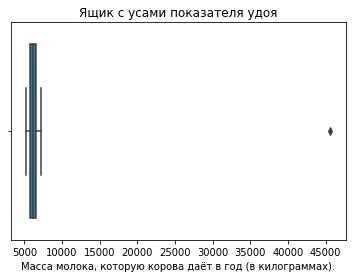

In [20]:
sns.boxplot(x=ferma_main['удой'])
plt.title('Ящик с усами показателя удоя')
plt.xlabel('Масса молока, которую корова даёт в год (в килограммах).')
plt.show()

In [21]:
print('Количество выбросов', (ferma_main['удой'] > 30000).sum())

Количество выбросов 1


Выброс. Наверно опечатка. Вместо 45616 должно было быть 4561,6. Но это значение одно. Удалим.

In [22]:
ferma_main = ferma_main[ferma_main['удой'] <= 40000]
sns.boxplot(x=ferma_main['удой'], color='orange')
plt.title('Ящик с усами показателя удоя')
plt.xlabel('Масса молока, которую корова даёт в год (в килограммах).')
plt.show()

SyntaxError: keyword argument repeated: color (67553106.py, line 2)

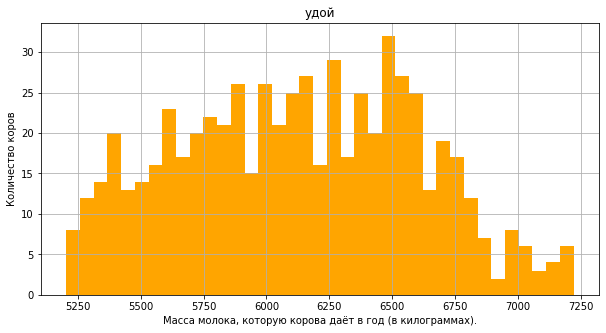

In [23]:
ferma_main['удой'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=37, color='orange')
plt.xlim()
plt.title('удой')
plt.xlabel('Масса молока, которую корова даёт в год (в килограммах).')
plt.ylabel('Количество коров')
plt.show()

Распределение нормальное.

Я построю подобные графики для каждого признака, учитывая, что количественным и категориальным признакам подходят разные графики.

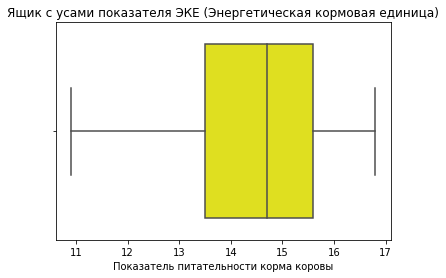

In [24]:
sns.boxplot(x=ferma_main['эке'], color='yellow')
plt.title('Ящик с усами показателя ЭКЕ (Энергетическая кормовая единица)')
plt.xlabel('Показатель питательности корма коровы')
plt.show()

Выбросов нет

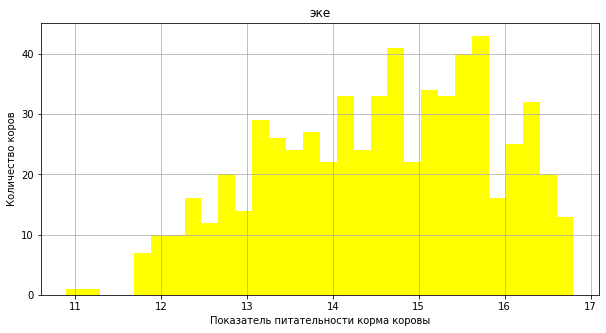

In [25]:
ferma_main['эке'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=30, color='yellow')
plt.xlim()
plt.title('эке')
plt.xlabel('Показатель питательности корма коровы')
plt.ylabel('Количество коров')
plt.show()

Распределение нормальное

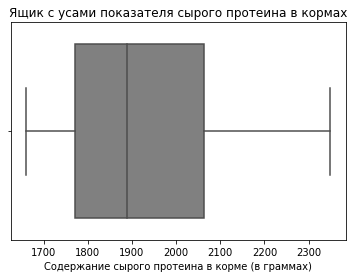

In [26]:
sns.boxplot(x=ferma_main['сырой_протеин'], color='gray')
plt.title('Ящик с усами показателя сырого протеина в кормах')
plt.xlabel('Содержание сырого протеина в корме (в граммах)')
plt.show()           

Выбросов нет

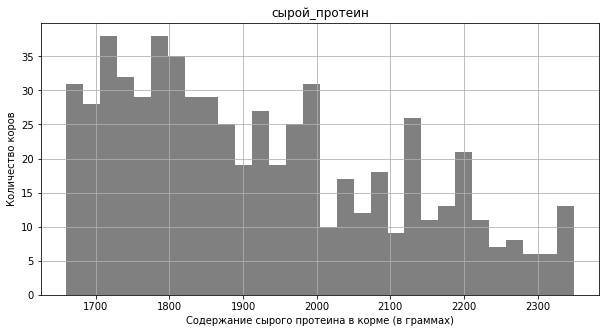

In [68]:
ferma_main['сырой_протеин'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=30, color='gray')
plt.xlim()
plt.title('сырой_протеин')
plt.xlabel('Содержание сырого протеина в корме (в граммах)')
plt.ylabel('Количество коров')
plt.show()

Распределение ненормальное, ассиметричное

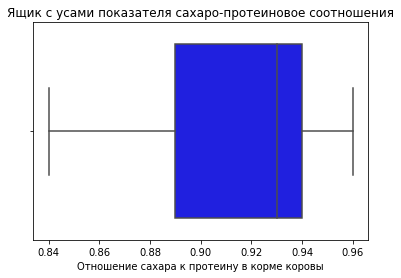

In [28]:
sns.boxplot(x=ferma_main['спо'], color='blue')
plt.title('Ящик с усами показателя сахаро-протеиновое соотношения')
plt.xlabel('Отношение сахара к протеину в корме коровы')
plt.show()   

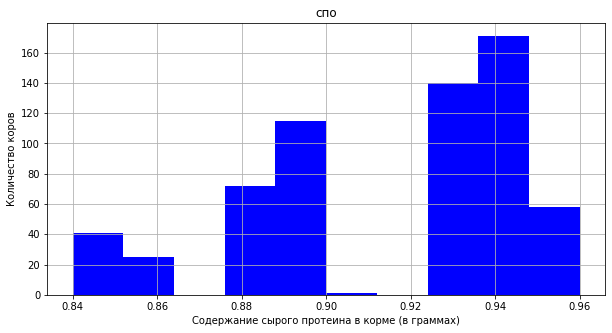

In [71]:
ferma_main['спо'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=10, color='blue')
plt.xlim()
plt.title('спо')
plt.xlabel('Содержание сырого протеина в корме (в граммах)')
plt.ylabel('Количество коров')
plt.show()

Распределение не распознать. (Трудно расспознать распределение, из-за отсутствия некоторых значений в данных)

Но я склонен думать, что оно более-менее нормальное с сильной склонностью вправо, как видно на медиане боксплота.

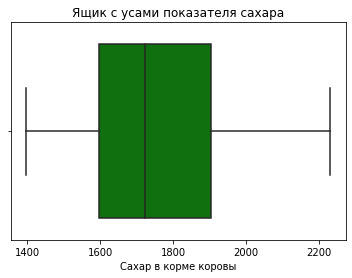

In [30]:
sns.boxplot(x=ferma_main['сахар'], color='green')
plt.title('Ящик с усами показателя сахара')
plt.xlabel('Сахар в корме коровы')
plt.show()   

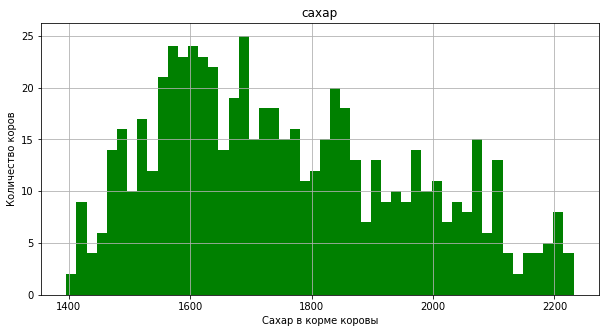

In [31]:
ferma_main['сахар'].plot(kind = 'hist', grid=True, figsize = (10,5), bins=50, color='green')
plt.xlim()
plt.title('сахар')
plt.xlabel('Сахар в корме коровы')
plt.ylabel('Количество коров')
plt.show()

Выбросов нет. Распределение нормальное.

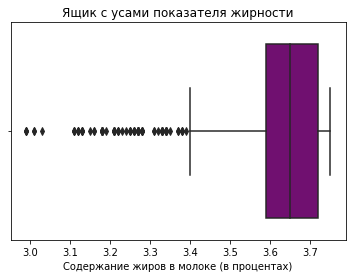

In [32]:
sns.boxplot(x=ferma_main['жирность'], color='purple')
plt.title('Ящик с усами показателя жирности')
plt.xlabel('Содержание жиров в молоке (в процентах)')
plt.show()           

Выбросы есть. Но их много. Проверим сколько их.

In [33]:
print('Количество выбросов', (ferma_main['жирность'] < 3.4).sum())
print("Процент выбросов",(ferma_main['жирность'] < 3.4).sum() / len(ferma_main)) 

Количество выбросов 86
Процент выбросов 0.13694267515923567


13% Это много.

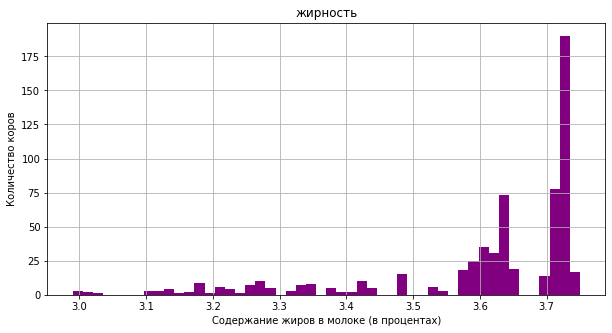

In [34]:
ferma_main['жирность'].plot(kind = 'hist', grid=True, figsize = (10,5), bins= 50, color='purple')
plt.xlim()
plt.title('жирность')
plt.xlabel('Содержание жиров в молоке (в процентах)')
plt.ylabel('Количество коров')
plt.show()

Распределение ненормальное, даже без учета выбросов. Но эти выбросы мы удалять не будем, поскольку 

1)параметр жирность не сильно важен в нашей задаче

2)Удаление выбросов, или замена их на медиану ничего хорошего не сделает из-за того, что выбросов много

3)Жирность молока - это, судя по всему, такой параметр, когда молоко либо жирное, либо нет. Это видно по боксплоту и по диаграмме. Если перевести его в бинарный категориальный признак ('жирность' >= 3.55) - жирное, то проблемы с распределением можно проигнорировать. 


(Я проведу этот эксперимент ниже phik matrix, но без этого, с выбросами зависимость удоя от жирности = 0.782808)

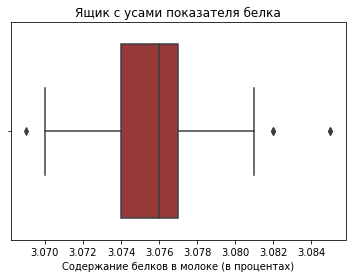

In [35]:
sns.boxplot(x=ferma_main['белок'], color='brown')
plt.title('Ящик с усами показателя белка')
plt.xlabel('Содержание белков в молоке (в процентах)')
plt.show()           

In [36]:
print('Количество выбросов', ((ferma_main['белок'] < 3.070) | (ferma_main['белок'] > 3.081)).sum())

Количество выбросов 5


5 выбросов, можно удалять

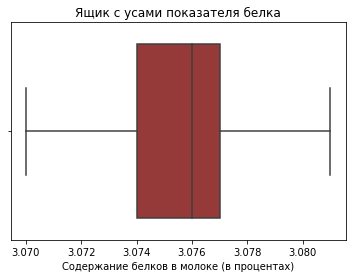

In [37]:
ferma_main = ferma_main[(ferma_main['белок'] >= 3.070) & (ferma_main['белок'] <= 3.081)]
sns.boxplot(x=ferma_main['белок'], color='brown')
plt.title('Ящик с усами показателя белка')
plt.xlabel('Содержание белков в молоке (в процентах)')
plt.show()    

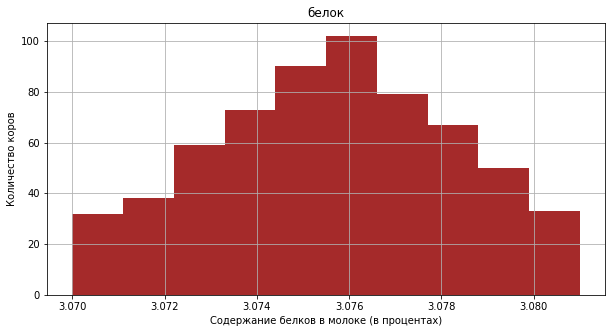

In [46]:
ferma_main['белок'].plot(kind = 'hist', grid=True, figsize = (10,5), bins= 10, color='brown')
plt.xlim()
plt.title('белок')
plt.xlabel('Содержание белков в молоке (в процентах)')
plt.ylabel('Количество коров')
plt.show()

Удалил. Распределение нормальное

С колличественными признаками ferma_main разобрались. Переходим к категориальным.

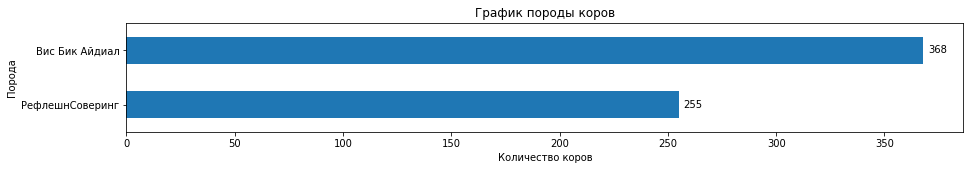

In [47]:
ax = ferma_main['порода'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='График породы коров'
)


for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')


plt.xlabel('Количество коров')
plt.ylabel('Порода')


plt.show()

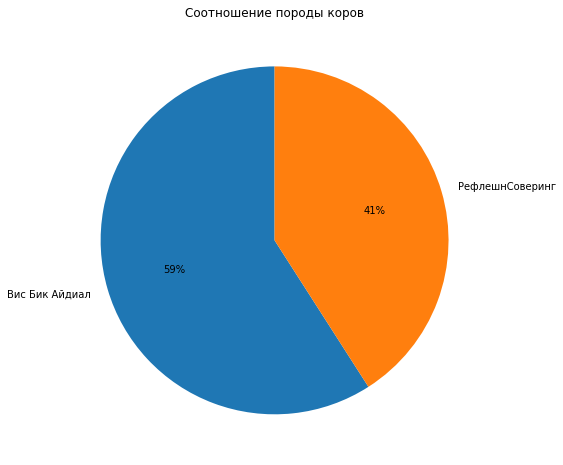

In [48]:
ax = ferma_main.pivot_table(index='порода', values='id', aggfunc='count').reset_index()

plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['порода'], startangle=90, autopct = "%.0f%%")
plt.title('Соотношение породы коров')
plt.show()

Почти поровну, но пород Айдиал все же больше.

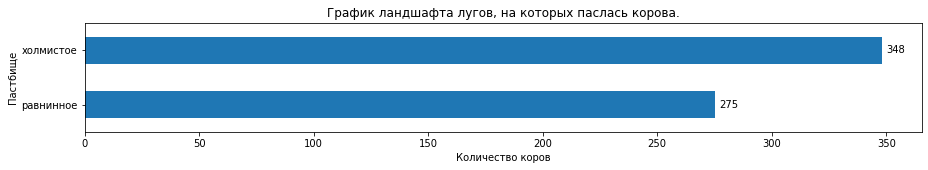

In [49]:
ax = ferma_main['тип_пастбища'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='График ландшафта лугов, на которых паслась корова.'
)


for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')


plt.xlabel('Количество коров')
plt.ylabel('Пастбище')


plt.show()

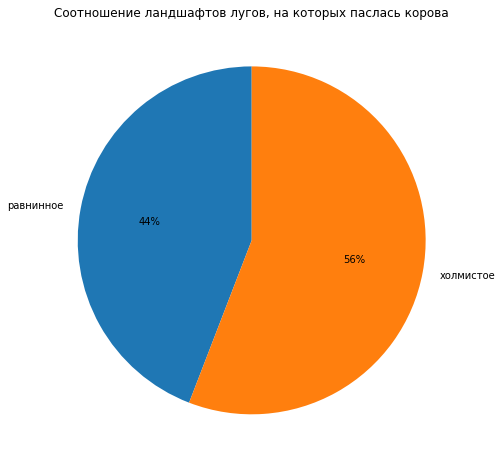

In [50]:
ax = ferma_main.pivot_table(index='тип_пастбища', values='id', aggfunc='count').reset_index()

plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['тип_пастбища'], startangle=90, autopct = "%.0f%%")
plt.title('Соотношение ландшафтов лугов, на которых паслась корова')
plt.show()

Коров с холмистых пастбищ больше, но не намного.

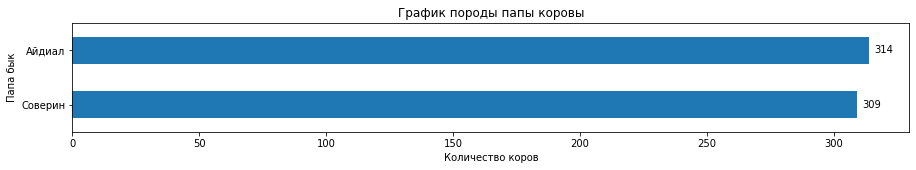

In [51]:
ax = ferma_main['порода_папы_быка'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='График породы папы коровы'
)


for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')


plt.xlabel('Количество коров')
plt.ylabel('Папа бык')


plt.show()

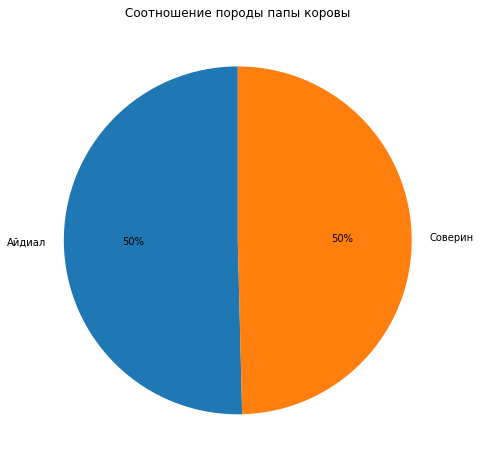

In [52]:
ax = ferma_main.pivot_table(index='порода_папы_быка', values='id', aggfunc='count').reset_index()

plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['порода_папы_быка'], startangle=90, autopct = "%.0f%%")
plt.title('Соотношение породы папы коровы')
plt.show()

Соотношение пород пап быков примерно одинаковое. Айдиалов всего на 5 голов больше

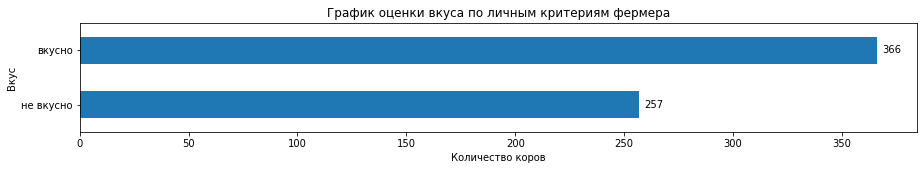

In [53]:
ax = ferma_main['вкус_молока'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='График оценки вкуса по личным критериям фермера'
)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')
plt.xlabel('Количество коров')
plt.ylabel('Вкус')
plt.show()

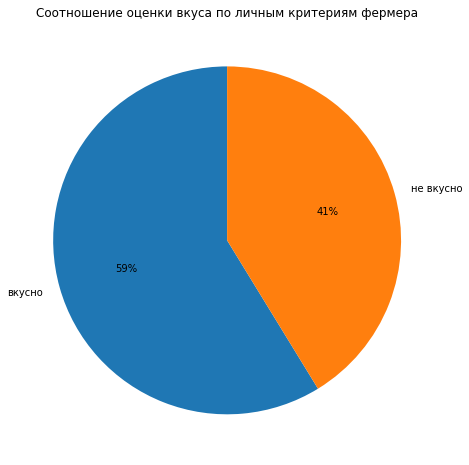

In [54]:
ax = ferma_main.pivot_table(index='вкус_молока', values='id', aggfunc='count').reset_index()

plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['вкус_молока'], startangle=90, autopct = "%.0f%%")
plt.title('Соотношение оценки вкуса по личным критериям фермера')
plt.show()

Большая часть коров дает вкусное молоко, но печально видеть, что и не вкусного молока много. Исходя из диаграммы их почти поровну.

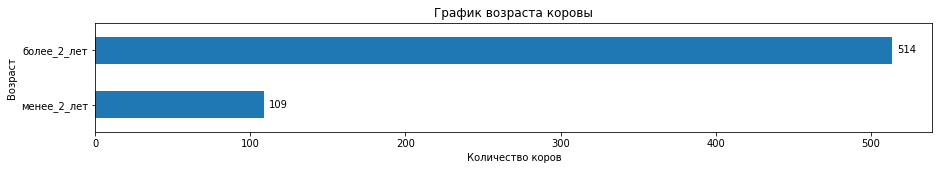

In [55]:
ax = ferma_main['возраст'].value_counts(ascending=True).plot(
    kind='barh',
    figsize=(15, 2),
    title='График возраста коровы'
)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')
plt.xlabel('Количество коров')
plt.ylabel('Возраст')
plt.show()

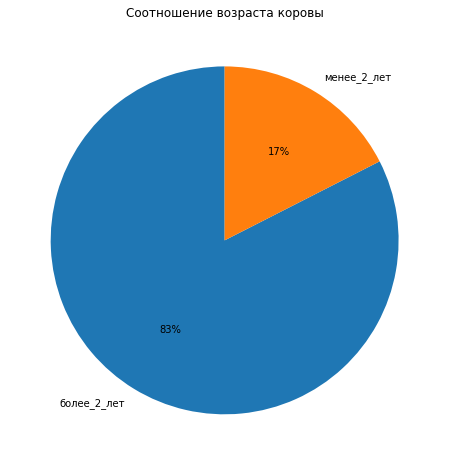

In [56]:
ax = ferma_main.pivot_table(index='возраст', values='id', aggfunc='count').reset_index()

plt.figure(figsize=(8, 8))
plt.pie(ax['id'], labels=ax['возраст'], startangle=90, autopct = "%.0f%%")
plt.title('Соотношение возраста коровы')
plt.show()

Тут уже нельзя сказать о том, что их поровну. Очень мало молодых коров по сравнению с теми, кто старше 2 лет.

Ну тут видимо сказывается то, что они растут - их возраст неумолимо повышается и молодых коров становится все меньше и меньше.

Зачем нужно распределение по возрасту? Возможно, коровы младше 2 лет не выдают молока или выдают его очень мало, но фермер взял их 'на вырост', по дешевой цене что бы они окупили себя в будущем.

Для нас это бы означало, что лучше не брать эту характеристику в модель. Ведь если это правда, то при покупке только взрослых коров, фермер рисковал бы не приобрести "скрытый алмаз, среди буренок, которая еще не раскрыла свой потенциал". Еще и по дешевой цене. Но тут уже вопрос (кроме расширения выборки) экономический. Тут надо уточнить эти условия в выводе, если в будущем клиент захочет доработать модель.

А так, в целом, распределение коров не поровну.

In [57]:
ferma_main.head()

,id,удой,эке,сырой_протеин,спо,порода,тип_пастбища,порода_папы_быка,жирность,белок,вкус_молока,возраст,сахар
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет,1551.270
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,равнинное,Соверин,3.54,3.079,вкусно,менее_2_лет,1902.820
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет,1640.790
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет,1780.620
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,равнинное,Соверин,3.73,3.073,вкусно,менее_2_лет,1482.375


Промежуточный вывод. Большинство признаков распределены нормально. (более-менее нормально)

Убраны аномальные значение признаков 'удой' и 'белок'.

Признак 'жирность' не был изменен.

## Корреляционный анализ

Сейчас проведем корреляционный анализ признаков в датасете ferma_main.csv

Сначала изучим взаимосвязь между признаками: рассчитаем коэффициенты корреляции между всеми признаками.

Сосредоточимся на Удое (это целевой признак, и его необходимо спрогнозировать по заданию)

In [75]:
ferma_main_encoded = pd.get_dummies(ferma_main, drop_first=True) # тут я перевожу категориальные признаки в количественные
ferma_main_encoded.drop('id', axis=1, inplace=True)



ferma_main_encoded['жирность'] = ferma_main_encoded['жирность'].apply(lambda x: 1 if x >= 3.55 else 0) #эксперимент


ferma_main_encoded.head()
#ferma_main_matrix = ferma_main_encoded.corr() #что бы в дальнейшем построить график зависимостей от них

#plt.figure(figsize=(10, 8))
#sns.heatmap(ferma_main_matrix, annot=True, cmap='coolwarm')
#plt.title('Корреляционная матрица признаков')
#plt.show()


,удой,эке,сырой_протеин,спо,жирность,белок,сахар,порода_РефлешнСоверинг,тип_пастбища_холмистое,порода_папы_быка_Соверин,вкус_молока_не вкусно,возраст_менее_2_лет
0,5863,14.2,1743,0.890,1,3.076,1551.270,0,0,0,0,0
1,5529,12.8,2138,0.890,0,3.079,1902.820,0,0,1,0,1
2,5810,14.0,1854,0.885,1,3.074,1640.790,1,1,1,1,0
3,5895,12.4,2012,0.885,0,3.075,1780.620,1,1,0,1,0
4,5302,12.8,1675,0.885,1,3.073,1482.375,0,0,1,0,1


In [76]:
!pip install phik -q
import phik

#c interval_cols не работает. Выдает ложные значения. phik и без него неплохо разделил
#phik_matrix = ferma_main_encoded.phik_matrix(interval_cols=['эке', 'сырой_протеин', 'спо', 'жирность', 'белок', 'сахар']) 

phik_matrix = ferma_main_encoded.phik_matrix(interval_cols=[])
display(phik_matrix['удой']) #выведу только столбец с ключевым признаком, так как именно его мы анализируем

удой                        1.000000
эке                         0.929525
сырой_протеин               0.000000
спо                         0.909434
жирность                    0.842410
белок                       0.650598
сахар                       0.987212
порода_РефлешнСоверинг      0.502741
тип_пастбища_холмистое      0.000000
порода_папы_быка_Соверин    0.613422
вкус_молока_не вкусно       0.000000
возраст_менее_2_лет         0.995340
Name: удой, dtype: float64

In [160]:
#display(phik_matrix['вкус_молока_не вкусно'])


Построим диаграммы рассеяния scatterplot для признака Удой, кг и всех количественных признаков с учётом значения категориальных признаков.

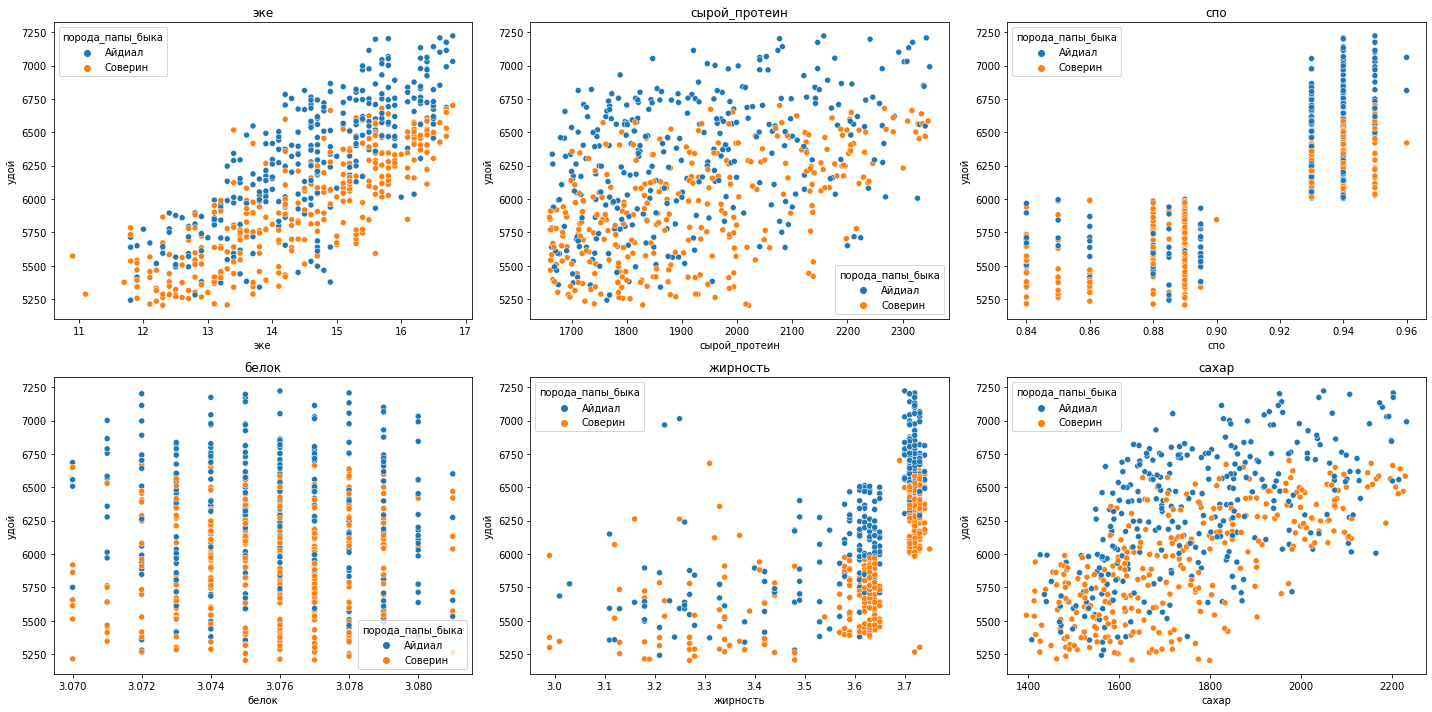

In [80]:
plt.figure(figsize=(20, 10))

for i, f in enumerate(['эке', 'сырой_протеин', 'спо', 'белок','жирность', 'сахар'], 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=ferma_main, x=f, y='удой', hue='порода_папы_быка')
    plt.title(f'{f}')

plt.tight_layout()
plt.show()

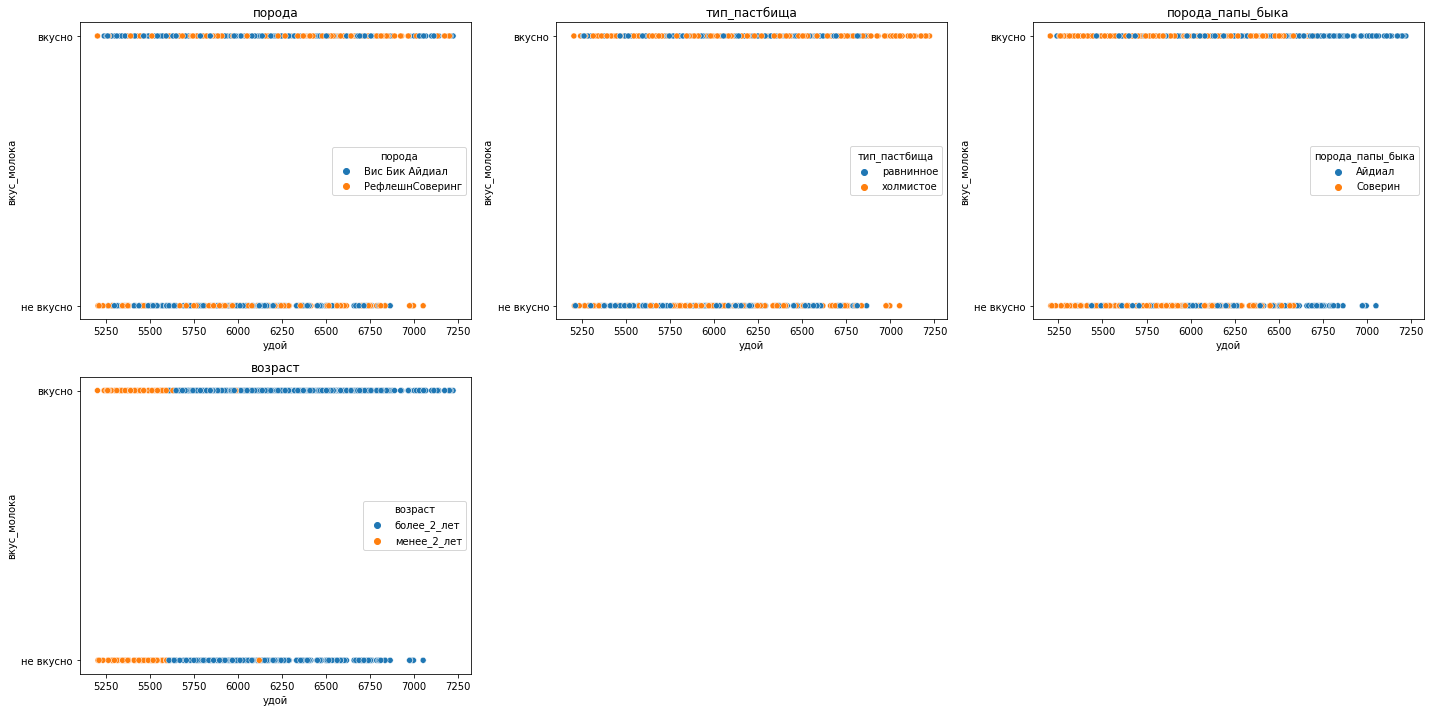

In [81]:
plt.figure(figsize=(20, 10))

for i, f in enumerate(['порода','тип_пастбища', 'порода_папы_быка', 'возраст'], 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=ferma_main, x='удой', y='вкус_молока', hue= f)
    plt.title(f'{f}')

plt.tight_layout()
plt.show()

Коровы с возрастом менее 2 лет имеют отрицательную взаимосвязь с удой, эке, спо, жирность.

В то время, как удой, эке, спо, сырой_протеин, жирность имеют положительную взаимосвязь между собой.


А какой тип взаимосвязи между целевым (удой) и входными признаками? Ответ представлен ниже
    
    КОЛИЧЕСТВЕННЫЕ ПРИЗНАКИ
    
1) Эке - 0.929525. На диаграмме видно, что есть постепенный прирост удоя в зависимости от увеличения эке. Это утверждение справедливо для всех пород. Наблюдается нелинейная сильная связь.

2) Сырой протеин 0.00. Взаимосвязи нет. И на диаграмме слишком большой разброс.

3) Спо - 0.909434. Наблюдается нелинейная связь. На графике странная взаимосвязь, которая показывает увеличение удоя в зависимости от роста соотношения сахара и протеина. То есть, между 0.93 и 0.95 есть скачок вверх по удою. Но для корректного ответа надо рассмотреть сахар. 
    3.1) ГРАНИЦА КЛАСТЕРА, ГДЕ ПРОИСХОДИТ ПОВЫШЕНИЕ НАХОДИТСЯ НА ОТМЕТКЕ 0.91. В БУДУЩЕМ ИСПОЛЬЗУЕМ, ЧТО БЫ ПРЕОБРАЗВАТЬ СПО В КАТЕГОРИАЛЬНЫЙ БИНАРНЫЙ ПРИЗНАК.

4) Жирность - 0.782808. На графике видно, что взаимосвязь проявляется в основном на значениях 3.6 и 3.7. Так как нет промежуточных (более дробных) значений, то явную взаимосвязь трудно разглядеть. Но так как на phik_matrix есть положительная связь, то можно о ней утверждать? Нет, потому что это не имеет никакого отношения в итоге. Что бы узнать жирность молока, необходимо собрать удой, а значит делать прогнозы по жирности бессмыслено.


5) Белок- 0.650598. Взаимосвязь выше среднего. На графике видно, что порода папы Айдиал выдает более белковосодержащий удой. Да и в целом Айдиал на порядок лучше Соверин. Нелинейна связь. Но, ситуация такая же, как и с жирностью.

6) Сахар 0.987212. Ситуация абсолютно не аналогична с протеином, сахар имеет гораздо большее влияние на удой, чем сырой протеин. На диаграмме разброс чуть меньше, а взаимосвязь на хетмапе больше. Видимо, сахар влияет на удой, в отличие от протеина. И это влияние более положительное. Однако, я не буду советовать добавлять больше сахара. Не зря существует колонка спо. Скорее всего, содержание сахара в корме не должно превышать содержание сырого протеина.


    КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ

1) Порода. 0.502741 Средняя связь есть


2) Тип пастбища. 0.000000 Нет связи. Не важно, где они пасутся.

3) Порода папы быка. 0.613422) Вот в этом случае порода сыграла какую то роль, что видно на диаграмме.

4) Вкус молока. 0.000000 Вкус молока на удой не влияет. 

5) Возраст. Из категориальных признаков, тут наблюдается самая явная взаимосвязь. Положительная связь (0.995340) у коров, старше 2 лет. Исходя из графика, можно сделать вывод, что молодые коровы приносят меньше удоя, чем те, которые старше 2 лет. Эта взаимосвязь была бы более явной, будь коров старше 2 лет и младше 2 лет поровну.


## Обучение модели линейной регрессии

Мне предстоит обучить три модели простой линейной регрессии.

Подготовлю данные датасета ferma_main.csv и обучу на них первую модель LinearRegression.

При подготовке данных, я уберу из неё лишние признаки, которые могут помешать модели обучаться.
'id' я убрал, потому что это лишь номер
'белок' и 'жирность' я убрал, потому что тут причинно-следственные связи нарушены и эти параметры узнаются только после удоя.
Столбец 'порода' я не беру, потому что на результат влияет только порода папы быка.

Модель 1

In [82]:
RANDOM_STATE = 42

X = ferma_main[['эке', 'сырой_протеин', 'спо', 'тип_пастбища', 'порода_папы_быка', 'возраст', 'сахар']]
y = ferma_main['удой']


Разбью данные на тренировочную и тестовую выборки, используя в качестве целевого признака Удой.


In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=RANDOM_STATE,
)


X_train.shape

(467, 7)

Кодирую категориальные признаки с помощью OneHotEncoder.


In [84]:
encoder = OneHotEncoder(drop='first', sparse=False, handle_unknown='error')
categorical_names = ['тип_пастбища', 'возраст', 'порода_папы_быка']
X_train_ohe = encoder.fit_transform(X_train[categorical_names])
X_test_ohe = encoder.transform(X_test[categorical_names])
encoder_col_names = encoder.get_feature_names()

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

In [85]:
print(X_train_ohe.head())
print(X_test_ohe.head())

   x0_холмистое  x1_менее_2_лет  x2_Соверин
0           0.0             0.0         1.0
1           0.0             0.0         0.0
2           0.0             0.0         0.0
3           0.0             0.0         0.0
4           0.0             0.0         0.0
   x0_холмистое  x1_менее_2_лет  x2_Соверин
0           1.0             0.0         1.0
1           0.0             1.0         1.0
2           1.0             0.0         0.0
3           1.0             0.0         1.0
4           1.0             0.0         1.0


Масштабирую количественные признаки с помощью StandardScaler.

In [86]:
quantitative_names = ['эке', 'сырой_протеин', 'спо', 'сахар']
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[quantitative_names])
X_test_scaled = scaler.transform(X_test[quantitative_names])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=quantitative_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=quantitative_names)

In [87]:
print(X_train_scaled.head())
print(X_test_scaled.head())

        эке  сырой_протеин       спо     сахар
0  1.543027       0.206082  1.426018  0.594318
1  1.388625      -0.185338  0.795084  0.068593
2 -0.386997       0.265882 -0.782250 -0.033751
3 -0.927403      -0.832267 -1.097716 -1.004279
4  0.076209      -1.397651 -1.097716 -1.453945
        эке  сырой_протеин       спо     сахар
0 -0.695800       0.091918 -0.782250 -0.173682
1 -2.085417      -1.446578 -2.359584 -1.819496
2  1.465826       0.836702  0.795084  0.936875
3 -0.541398      -1.066031 -1.097716 -1.190199
4  0.925419      -1.158450  0.479618 -0.842385


Обучаю модель линейной регрессии на подготовленных данных.


In [88]:
X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

In [89]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
predictions = model_lr.predict(X_test)

Оценив качество модели на тестовой выборке я рассчитываю R².

Проанализирую остатки с помощью графиков.


In [90]:
ss_res_1 = np.sum((y_test - predictions) ** 2)


ss_tot_1 = np.sum((y_test - np.mean(y_test)) ** 2)


print("R2 LinearRegression =", 1 - (ss_res_1 / ss_tot_1))

R2 LinearRegression = 0.7914628985273334


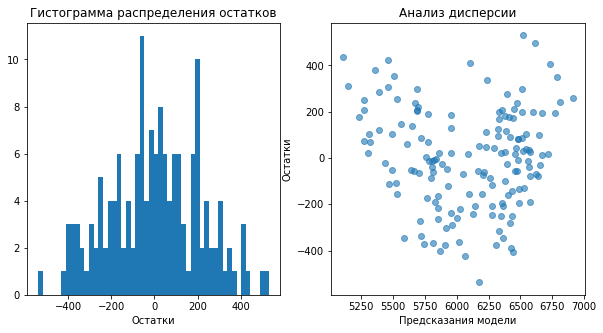

In [91]:
residuals = y_test - predictions
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axes[0].hist(residuals, bins=50)
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

axes[1].scatter(predictions, residuals, alpha=0.6)
axes[1].set_title('Анализ дисперсии')
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
plt.show()

Промежуточный вывод.

R² модели 1 = 0.7914628985273334.

То есть модель показывает себя хорошо в 79%.

Остатки несеметричны, но распределение нормальное

Остатки имеют пик слева(большое значение), что возможно, означает то, что модель склонна преувеличивать результаты.

Но это нельзя утверждать наверняка, потому что справа тоже есть большое значение.
Для улучшенного моделирования стоит дополнительно получить информацию по коровам, удой которых находится в интервале значений 5800-6300, потому как модель не очень точно предсказывает значения целевого признака. Нужны дополнительные исследования.

Сейчас я подготовлю данные с учётом связи входных признаков с целевым и обучу на них вторую модель LinearRegression.


In [95]:
# на этот раз обучение будет на отдельном датафрейме (копии)
ferma_linearregression_mod = ferma_main.copy(deep=True)

ferma_linearregression_mod.head()

,id,удой,эке,сырой_протеин,спо,порода,тип_пастбища,порода_папы_быка,жирность,белок,вкус_молока,возраст,сахар
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет,1551.270
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,равнинное,Соверин,3.54,3.079,вкусно,менее_2_лет,1902.820
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет,1640.790
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет,1780.620
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,равнинное,Соверин,3.73,3.073,вкусно,менее_2_лет,1482.375


Обнаружено, что СПО и Удой связаны нелинейно. На их диаграмме рассеяния наблюдения сгруппированы в два кластера, причём есть такое значение СПО, которое можно считать границей между кластерами (на графике выше можно увидеть скачок вверх после 0.9).

Чтобы устранить нелинейность, преобразую СПО в категориальный бинарный признак, использовав эту границу.

In [96]:
ferma_linearregression_mod['спо'] = ferma_linearregression_mod['спо'].apply(lambda x: 1 if x >= 0.91 else 0)
display(ferma_linearregression_mod['спо'].value_counts())

1    369
0    254
Name: спо, dtype: int64

In [97]:
#Я исключаю нелинейность, введя ЭКЕ в квадрате.(так в тз написано, может надо было сделать это раньше? Для диаграмм.)
ferma_linearregression_mod['эке_2'] = ferma_linearregression_mod['эке'] ** 2

ferma_linearregression_mod = ferma_linearregression_mod.drop(['id', 'белок', 'жирность', 'эке', 'спо', 'порода'], axis=1)
#ferma_linearregression_mod = ferma_linearregression_mod.drop(['id', 'белок', 'жирность', 'эке', 'спо'], axis=1)
ferma_linearregression_mod.head()

,удой,сырой_протеин,тип_пастбища,порода_папы_быка,вкус_молока,возраст,сахар,эке_2
0,5863,1743,равнинное,Айдиал,вкусно,более_2_лет,1551.270,201.64
1,5529,2138,равнинное,Соверин,вкусно,менее_2_лет,1902.820,163.84
2,5810,1854,холмистое,Соверин,не вкусно,более_2_лет,1640.790,196.00
3,5895,2012,холмистое,Айдиал,не вкусно,более_2_лет,1780.620,153.76
4,5302,1675,равнинное,Соверин,вкусно,менее_2_лет,1482.375,163.84



Повторяю шаги, которые делал с первой моделью и создам вторую модель.


In [98]:
X = ferma_linearregression_mod.drop('удой', axis=1) #перенесу этот признак, ведь он ключевой
y = ferma_linearregression_mod['удой']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=RANDOM_STATE,
)

 Кодируем категориальные признаки c помощью OneHotEncoder

In [99]:

o_h_encoder = OneHotEncoder(drop='first', sparse=False)
categorical_names = ['тип_пастбища', 'возраст', 'порода_папы_быка', 'вкус_молока']
X_train_ohe = o_h_encoder.fit_transform(X_train[categorical_names])
X_test_ohe = o_h_encoder.transform(X_test[categorical_names])
o_h_encoder_col_names = o_h_encoder.get_feature_names()

X_train_ohe = pd.DataFrame(X_train_ohe, columns=o_h_encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=o_h_encoder_col_names)

Масштабируем количественные признаки с помощью StandardScaler

In [100]:

quantitative_names = ['сырой_протеин', 'сахар', 'эке_2']
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[quantitative_names])
X_test_scaled = scaler.transform(X_test[quantitative_names])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=quantitative_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=quantitative_names)


print(X_train_scaled.head())
print(X_test_scaled.head())

   сырой_протеин     сахар     эке_2
0       0.206082  0.594318  1.626057
1      -0.185338  0.068593  1.449208
2       0.265882 -0.033751 -0.430475
3      -0.832267 -1.004279 -0.946283
4      -1.397651 -1.453945  0.032546
   сырой_протеин     сахар     эке_2
0       0.091918 -0.173682 -0.728438
1      -1.446578 -1.819496 -1.963160
2       0.836702  0.936875  1.537365
3      -1.066031 -1.190199 -0.580528
4      -1.158450 -0.842385  0.931525


In [101]:
X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

In [102]:
model_lr_2 = LinearRegression()
model_lr_2.fit(X_train, y_train)
predictions_2 = model_lr_2.predict(X_test) 

In [103]:
ss_res_2 = np.sum((y_test - predictions_2) ** 2)


ss_tot_2 = np.sum((y_test - np.mean(y_test)) ** 2)


print("R2 LinearRegression =",  1 - (ss_res_2 / ss_tot_2))

R2 LinearRegression = 0.8013853656819411


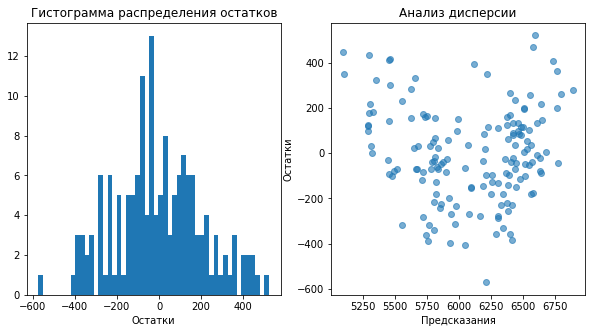

In [104]:
residuals_2 = y_test - predictions_2
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axes[0].hist(residuals_2, bins=50)
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

axes[1].scatter(x=predictions_2, y=residuals_2, alpha=0.6)
axes[1].set_title('Анализ дисперсии')
axes[1].set_xlabel('Предсказания')
axes[1].set_ylabel('Остатки')
plt.show()

R2 = 0.8013853656819411.

In [105]:
0.8013853656819411 - 0.7914628985273334

0.00992246715460765

Слегка лучше, чем первая.(на 1%)

Остатки теперь имеют нормальное распределение, но теперь точно смещены влево. Модель все еще преувеличивает значения. 

Теперь я добавлю в данные новый признак и обучу на них третью модель LinearRegression.

Добавлю признак Имя Папы из файла ferma_dad.csv, соединив его с остальными данными ferma_main.csv по ключу.

In [106]:
ferma = ferma_main.merge(ferma_dad, on='id', how='left')
ferma['эке_2'] = ferma['эке'] ** 2
print(ferma.info())
ferma.head(1)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 623 entries, 0 to 622
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                623 non-null    int64  
 1   удой              623 non-null    int64  
 2   эке               623 non-null    float64
 3   сырой_протеин     623 non-null    int64  
 4   спо               623 non-null    float64
 5   порода            623 non-null    object 
 6   тип_пастбища      623 non-null    object 
 7   порода_папы_быка  623 non-null    object 
 8   жирность          623 non-null    float64
 9   белок             623 non-null    float64
 10  вкус_молока       623 non-null    object 
 11  возраст           623 non-null    object 
 12  сахар             623 non-null    float64
 13  имя_папы          623 non-null    object 
 14  эке_2             623 non-null    float64
dtypes: float64(6), int64(3), object(6)
memory usage: 77.9+ KB
None


,id,удой,эке,сырой_протеин,спо,порода,тип_пастбища,порода_папы_быка,жирность,белок,вкус_молока,возраст,сахар,имя_папы,эке_2
0,1,5863,14.2,1743,0.89,Вис Бик Айдиал,равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет,1551.27,Буйный,201.64


In [107]:
X = ferma[['эке_2', 'сырой_протеин', 'спо', 'порода', 'тип_пастбища', 'возраст', 'порода_папы_быка', 'имя_папы', 'сахар']]

y = ferma['удой']

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=RANDOM_STATE
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(467, 9)
(156, 9)
(467,)
(156,)


In [109]:
#cat_col_names = ['спо', 'порода', 'тип_пастбища', 'возраст', 'порода_папы_быка', 'имя_папы']
cat_col_names = ['тип_пастбища', 'возраст', 'порода_папы_быка', 'имя_папы']


encoder = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])
encoder_col_names = encoder.get_feature_names()


X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)
num_col_names = ['эке_2', 'сырой_протеин', 'сахар']
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

In [110]:
num_col_names = ['эке_2', 'сырой_протеин', 'сахар']
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)


In [111]:
X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

In [112]:
model_lr_3 = LinearRegression()
model_lr_3.fit(X_train, y_train)
predictions_3 = model_lr_3.predict(X_test)

In [113]:
ss_res_3 = np.sum((y_test - predictions_3) ** 2)


ss_tot_3 = np.sum((y_test - np.mean(y_test)) ** 2)


print("R2 LinearRegression =",  1 - (ss_res_3 / ss_tot_3))

R2 LinearRegression = 0.8114194237013207


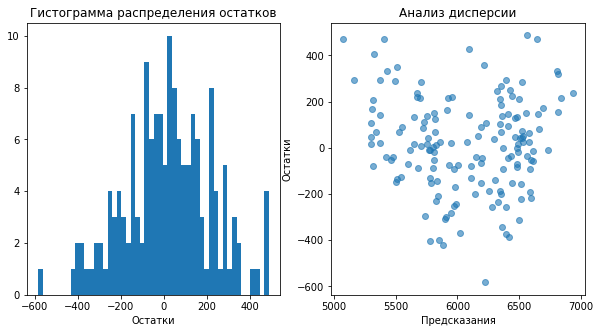

In [114]:
residuals_3 = y_test - predictions_3
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axes[0].hist(residuals_3, bins=50)
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

axes[1].scatter(x=predictions_3, y=residuals_3, alpha=0.6)
axes[1].set_title('Анализ дисперсии')
axes[1].set_xlabel('Предсказания')
axes[1].set_ylabel('Остатки')
plt.show()

Промежуточные выводы

R2 = 0.843787936238019
 
 
говорит о том, что модель хорошо себя показывает в 84% случаев. Остатки склоняются уже вправо.

In [115]:
print('Третья модель предсказывает на', 
      (0.843787936238019 * 100 - 0.8013853656819411* 100), 
      '% лучше чем вторая и на', 
      (0.843787936238019* 100 - 0.7914628985273334* 100), 
      '% лучше чем первая.')

Третья модель предсказывает на 4.240257055607785 % лучше чем вторая и на 5.232503771068551 % лучше чем первая.


Я мог бы сказать, что считаю это ОЧЕНЬ хорошим результатом. Наша цель в предсказание 6000 кг молока в год имеет не такие жесткие рамки, что бы можно было беспокоится о 16% неудач. Но эта модель все еще может стать лучше.

Так же в остатках присутсвует симметрия, но она очень сильно склоняется вправо. Модель преуменьшает предсказания.


Сравниваю качество трёх моделей линейной регрессии, сопоставляя их R² и остатки.

первая модель: R2 = 0.7914;

вторая модель: R2 = 0.8013;

третья модель: R2 = 0.8437.

In [116]:
print('первая модель - остатки в среднем:', residuals.mean())
print('вторая модель - остатки в среднем:', residuals_2.mean())
print('третья модель - остатки в среднем:', residuals_3.mean())

первая модель - остатки в среднем: 0.7446464853087724
вторая модель - остатки в среднем: -0.12385424417150204
третья модель - остатки в среднем: 16.150079106254342


А третья модель уж слишком сильно занижает предсказания на фоне других.

Оценим качество каждой модели по трём метрикам: MSE, MAE, RMSE. 

(Я не использовал функции для расчёта метрик, потому что у меня что то пошло не так)

In [117]:
mse_1 = mean_squared_error(y_test, predictions)
mse_2 = mean_squared_error(y_test, predictions_2)
mse_3 = mean_squared_error(y_test, predictions_3)


print('MSE первой модели:', mse_1)
print('MSE второй модели:', mse_2)
print('MSE третьей модели:', mse_3)

MSE первой модели: 45690.25431996797
MSE второй модели: 43516.2524537582
MSE третьей модели: 41317.80114927002


In [118]:
rmse_1 = mean_squared_error(y_test, predictions, squared=False)
rmse_2 = mean_squared_error(y_test, predictions_2, squared=False)
rmse_3 = mean_squared_error(y_test, predictions_3, squared=False)


print('RMSE первой модели:', rmse_1)
print('RMSE второй модели:', rmse_2)
print('RMSE третьей модели:', rmse_3)

RMSE первой модели: 213.75278786478546
RMSE второй модели: 208.6054947832348
RMSE третьей модели: 203.26780647527542


In [119]:
mae_1 = mean_absolute_error(y_test, predictions)
mae_2 = mean_absolute_error(y_test, predictions_2)
mae_3 = mean_absolute_error(y_test, predictions_3)


print('MAE первой модели:', mae_1)
print('MAE второй модели:', mae_2)
print('MAE третьей модели:', mae_3)

MAE первой модели: 171.93493086602516
MAE второй модели: 166.71584085260324
MAE третьей модели: 160.05412366243306


Ну, видимо добавление нового признака сделало ошибки в третьей модели минимальными на фоне двух других.

Я выбрал лучшую модель;

это третья


Сейчас мы укажем доверительный интервал прогноза лучшей модели.


In [120]:
# Посчитаем доверительный интервал лучшей модели 
print('доверительный интервал:',
      st.norm.interval(confidence=0.95, loc=np.mean(predictions_3), scale=st.sem(predictions_3)))

доверительный интервал: (6005.10598068576, 6141.952835460707)


Промежуточный вывод перед прогнозом.

Лучшая модель - третья.

MSE третьей модели: 34225.89491619782

RMSE третьей модели: 185.00241867661575

MAE третьей модели: 146.8912240179252

95% доверительный интервал лучшей модели = (6005.10598068576, 6141.952835460707) - Получили прогноз. Как и ожидалось - прогноз заниженный. Но в нашем случае, нам нужно 6000 кг и выше, а потому если модель покажет результат в 6000 кг, то с большей вероятностью истинное значение будет выше 6000 кг и клиент ничего не потеряет с этого предсказания и останется в плюсе.



А сейчас я буду с помощью лучшей модели прогнозировать удой коров, которых фермер хочет купить. Данные о них находятся в датасете cow_buy.csv.
Добавлю недостающие признаки ЭКЕ (Энергетическая кормовая единица), Сырой протеин, г и СПО (Сахаро-протеиновое соотношение)(возьму из датасета ferma_main.csv средние значения каждого из признаков и увеличу их на 5%).


(Следующая часть мне далась невероятно тяжело)

In [121]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 467 entries, 0 to 466
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   x0_холмистое    467 non-null    float64
 1   x1_менее_2_лет  467 non-null    float64
 2   x2_Соверин      467 non-null    float64
 3   x3_Буйный       467 non-null    float64
 4   x3_Геркулес     467 non-null    float64
 5   x3_Соловчик     467 non-null    float64
 6   эке_2           467 non-null    float64
 7   сырой_протеин   467 non-null    float64
 8   сахар           467 non-null    float64
dtypes: float64(9)
memory usage: 33.0 KB


In [122]:
X.head()

,эке_2,сырой_протеин,спо,порода,тип_пастбища,возраст,порода_папы_быка,имя_папы,сахар
0,201.64,1743,0.890,Вис Бик Айдиал,равнинное,более_2_лет,Айдиал,Буйный,1551.270
1,163.84,2138,0.890,Вис Бик Айдиал,равнинное,менее_2_лет,Соверин,Соловчик,1902.820
2,196.00,1854,0.885,РефлешнСоверинг,холмистое,более_2_лет,Соверин,Барин,1640.790
3,153.76,2012,0.885,РефлешнСоверинг,холмистое,более_2_лет,Айдиал,Буйный,1780.620
4,163.84,1675,0.885,Вис Бик Айдиал,равнинное,менее_2_лет,Соверин,Барин,1482.375


Выполняем подготовку данных, аналогичную той, которую делали для тренировочной выборки.


Нормализуем категориальные признаки для прогноза

In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=RANDOM_STATE,
)

X_train_full = pd.concat([X_train, X_test], ignore_index=True)
y_train_full = pd.concat([y_train, y_test], ignore_index=True)

cow_buy_copy = cow_buy.copy(deep=True)

#увеличиваем среднее на 5% (старый датасет не использую)
mean_values = ferma_main[['эке', 'сырой_протеин', 'спо']].mean()
new_values = mean_values * 1.05

cow_buy_copy['эке'] = new_values['эке']
cow_buy_copy['эке_2'] = new_values['эке'] ** 2
cow_buy_copy['сырой_протеин'] = new_values['сырой_протеин']
cow_buy_copy['спо'] = new_values['спо']

In [124]:

cat_col_names = ['порода', 'тип_пастбища', 'порода_папы_быка', 'возраст', 'имя_папы']
num_col_names = ['эке_2', 'сырой_протеин', 'спо']

Масштабируем количественные признаки:

In [125]:
encoder = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = encoder.fit_transform(X_train_full[cat_col_names])
X_test_ohe = encoder.transform(cow_buy_copy[cat_col_names])
encoder_col_names = encoder.get_feature_names()



Кодируем категориальные

In [126]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full[num_col_names])
X_test_scaled = scaler.transform(cow_buy_copy[num_col_names])

После масштабирования количественных признаков, мы объединим преобразованные количественные данные с категориальными, чтобы получить полный датафрейм для модели.

In [127]:
X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train_full = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test_full = pd.concat([X_test_ohe, X_test_scaled], axis=1)

.

In [128]:
%%time 
final_reg = LogisticRegression()
final_reg.fit(X_train_full, y_train_full)
predskazanie = final_reg.predict(X_test_full) #вот мы и получили список предсказанных значений
predskazanie

CPU times: user 2.31 s, sys: 1.77 s, total: 4.08 s
Wall time: 4.03 s


array([6133, 6122, 6173, 6501, 6501, 6173, 6133, 6248, 6173, 6501, 6084,
       6173, 6133, 6122, 6173, 6501, 6084, 6173, 6248, 6501])

Я добавлю этот столбец в оригинальный датафрем, что бы в будущем добавить к нему столбец с предсказанием вкуса.

In [129]:
cow_buy['предсказанный_удой'] = predskazanie #добавляем предсказания в датасет покупных коров, и сортируем по убыванию
cow_buy.sort_values(by='предсказанный_удой', ascending=False)

,порода,тип_пастбища,порода_папы_быка,имя_папы,текущая_жирность,текущий_белок,возраст,предсказанный_удой
19,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,6501
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,6501
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,6501
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,6501
15,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.065,более_2_лет,6501
18,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.34,3.069,более_2_лет,6248
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,6248
14,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,6173
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,6173
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.63,3.053,менее_2_лет,6173


Промежуточный вывод.

После работы мной был предсказан годовой удой продаваемых коров. И все выдадут нужный результат.


Более 6000 кг удоя в год было предсказано. 

Но есть НО. Будет ли этот удой вкусным???
необходимо спрогнозировать вкус логистической регрессией.

## Обучение модели логистической регрессии

Подготовлю данные датасета ferma_main.csv и обучу на них модель LogisticRegression.

Использую в качестве целевого признак Вкус молока.

При необходимости преобразую имеющиеся или добавлю новые признаки.



In [130]:
ferma_main_copy = ferma_main.copy()

Придется снова дополнять этот датасет необходимыми для расчета признаками, поскольку при использовании предыдущих копий у меня возникали NaN значения. 

Для этого мы добавим туда столбцы, которые добавляли ранее.

In [131]:
#превращаем вкус в бинарный признак. 1 - вкусно, 0 - не вкусно
ferma_main_copy['вкус_молока_вкус'] = ferma_main_copy['вкус_молока'].apply(lambda x: 1 if x == 'вкусно' else 0)

#есть такое значение СПО, которое можно считать границей между кластерами. Чтобы устранить нелинейность, преобразуем СПО в категориальный бинарный признак, использовав эту границу.
ferma_main_copy['спо_больше'] = ferma_main_copy['спо'].apply(lambda x: 1 if x > 0.91 else 0)
# ЭКЕ и Удой также связаны нелинейно. Нелинейность между ними можно исключить, возведя эке в квадрат
ferma_main_copy['эке_2'] = ferma_main_copy['эке'] ** 2


ferma_main_copy.head()

,id,удой,эке,сырой_протеин,спо,порода,тип_пастбища,порода_папы_быка,жирность,белок,вкус_молока,возраст,сахар,вкус_молока_вкус,спо_больше,эке_2
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет,1551.270,1,0,201.64
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,равнинное,Соверин,3.54,3.079,вкусно,менее_2_лет,1902.820,1,0,163.84
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет,1640.790,0,0,196.00
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет,1780.620,0,0,153.76
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,равнинное,Соверин,3.73,3.073,вкусно,менее_2_лет,1482.375,1,0,163.84


И убираем те, что расчету помешают. (При экспериментах с предыдущими моделями мной было выяснено, что удаление породы ухудшает модель)
Мы воспользуемся признаком 'вкус_молока_вкус'

In [132]:
ferma_main_copy = ferma_main_copy.drop(['id', 'удой','эке', 'вкус_молока', 'спо'], axis=1)
ferma_main_copy.head()

,сырой_протеин,порода,тип_пастбища,порода_папы_быка,жирность,белок,возраст,сахар,вкус_молока_вкус,спо_больше,эке_2
0,1743,Вис Бик Айдиал,равнинное,Айдиал,3.58,3.076,более_2_лет,1551.270,1,0,201.64
1,2138,Вис Бик Айдиал,равнинное,Соверин,3.54,3.079,менее_2_лет,1902.820,1,0,163.84
2,1854,РефлешнСоверинг,холмистое,Соверин,3.59,3.074,более_2_лет,1640.790,0,0,196.00
3,2012,РефлешнСоверинг,холмистое,Айдиал,3.40,3.075,более_2_лет,1780.620,0,0,153.76
4,1675,Вис Бик Айдиал,равнинное,Соверин,3.73,3.073,менее_2_лет,1482.375,1,0,163.84


Разбью данные на тренировочную и тестовую выборки.



In [134]:


X = ferma_main_copy.drop('вкус_молока_вкус', axis=1)
y = ferma_main_copy['вкус_молока_вкус'] #КЛЮЧЕВОЙ

X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=RANDOM_STATE)
X_train_full = pd.concat([X_train, X_test], ignore_index=True)
y_train_full = pd.concat([y_train, y_test], ignore_index=True)

Закодирую категориальные признаки с помощью OneHotEncoder.



In [135]:
cat_col_names = ['порода', 'тип_пастбища', 'порода_папы_быка', 'возраст', 'спо_больше']
num_col_names = ['жирность', 'белок', 'эке_2', 'сырой_протеин']
encoder = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])
encoder_col_names = encoder.get_feature_names()

Замасштабирую количественные признаки с помощью StandardScaler.



In [136]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])


In [137]:
X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

Обучу модель логистической регрессии на подготовленных данных.



In [138]:
print(X_train_scaled.isnull().sum())

жирность         0
белок            0
эке_2            0
сырой_протеин    0
dtype: int64


In [139]:
%%time
clf = LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', penalty='l1')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

CPU times: user 4.54 ms, sys: 3.87 ms, total: 8.41 ms
Wall time: 6.87 ms


Оцению качество модели на тестовой выборке (рассчитаю метрики accuracy, recall, precision).


In [140]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print('LogisticRegression model Accuracy = ', round(accuracy, 3))
print('LogisticRegression model Precision = ', round(precision, 3))
print('LogisticRegression model Recall = ', round(recall, 3))

LogisticRegression model Accuracy =  0.628
LogisticRegression model Precision =  0.631
LogisticRegression model Recall =  0.805


In [141]:
#for feature_number, feature_name in enumerate(X_train.columns):
#    exp_weight = math.exp(clf.coef_[0, feature_number])
#    print(f"{feature_name:<20}: {exp_weight:+.2f}")

Построю матрицу ошибок.


Text(0.5, 15.0, 'Predicted')

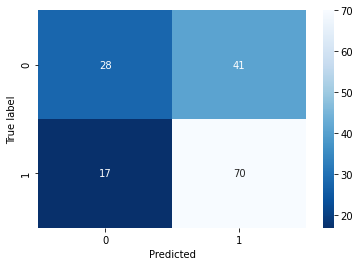

In [142]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('True label')
plt.xlabel('Predicted')

In [143]:
thresholds = [round(i,2) for i in np.linspace(0.5,1,num = 4,endpoint=False)]
print(thresholds)

[0.5, 0.62, 0.75, 0.88]


Из матрицы ошибок видно следующее:

    В 28 случаях модель правильно классифицировала вкусное молоко как 'вкусно'. tp
    
    В 41 случаях модель неправильно классифицировала невкусное молоко как 'вкусно', что является критической ошибкой. fp
    
    В 17 случае модель неправильно классифицировала вкусное молоко как 'невкусно', что можно считать некритичной ошибкой. fn
    
    В 70 случаях модель правильно классифицировала невкусное молоко как 'не вкусно'. tn

2) Проанализирую модель логистической регрессии.

(Объясню, какая ошибка критичнее всего при покупке коров: первого или второго рода (главное для заказчика — вкусное молоко).)

Фермер нам прямо говорит, что для него важно не покупать неподходящих коров, что если вместо вкусного молока будет предсказано невкусное, то заказчик не пострадает. В отличии от того, если будет наооборот. Тогда будет предсказано вкусное, а оно оказалось невкусным. Эта ошибка будет критичнее.

Это есть ошибка первого рода (ложноположительная) является наиболее критичной при покупке коров. Потому я ореинтироваться буду на Precision, при регулировании модели.

Сформулирую ответ с учётом метрик recall и precision (и выберу более важную из них).


Предсказание вероятностей и создание data 

In [145]:
y_proba = clf.predict_proba(X_test)[:,1]
data = pd.DataFrame(zip(y_test, y_proba), columns = ['y_test', 'y_proba'])
columns = []

for i in thresholds:
    columns.append('y_pred_'+str(i))
    data['y_pred_'+str(i)] = data['y_proba'].apply(lambda x: 1 if x >= i else 0)
data.head()

,y_test,y_proba,y_pred_0.5,y_pred_0.62,y_pred_0.75,y_pred_0.88
0,1,0.682441,1,1,0,0
1,0,0.263749,0,0,0,0
2,1,0.816960,1,1,1,0
3,0,0.607987,1,0,0,0
4,1,0.725505,1,1,0,0


In [146]:
# Эта функция возращает пороги(ТОЧНЕЕ ЦЕЛЫЙ ДАТАФРЕЙМ result_df с threshold)
def threshold_choice(threshold_list, proba_df):
    result_df = pd.DataFrame(columns=['threshold', 'precision', 'recall'])
    for threshold in threshold_list:
        column_name = 'y_pred_' + str(threshold)
        precision = proba_df.loc[proba_df[column_name] == 1, 'y_test'].mean()
        recall = proba_df.loc[(proba_df[column_name] == 1) & (proba_df['y_test'] == 1)].shape[
                     0] / (proba_df['y_test'].sum())
        result_df = result_df.append({
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
        }, ignore_index=True)

    return result_df

In [147]:
proba_data_1 = data.copy(deep=True)
thresholds_1 = [round(i, 2) for i in np.linspace(0.1, 1, num=10, endpoint=False)]
columns = []
for i in thresholds_1:
    columns.append('y_pred_' + str(i))
    proba_data_1['y_pred_' + str(i)] = proba_data_1['y_proba'].apply(lambda x: 1 if x > i else 0)
proba_data_1.head(5)

,y_test,y_proba,y_pred_0.5,y_pred_0.62,y_pred_0.75,y_pred_0.88,y_pred_0.1,y_pred_0.19,y_pred_0.28,y_pred_0.37,y_pred_0.46,y_pred_0.55,y_pred_0.64,y_pred_0.73,y_pred_0.82,y_pred_0.91
0,1,0.682441,1,1,0,0,1,1,1,1,1,1,1,0,0,0
1,0,0.263749,0,0,0,0,1,1,0,0,0,0,0,0,0,0
2,1,0.816960,1,1,1,0,1,1,1,1,1,1,1,1,0,0
3,0,0.607987,1,0,0,0,1,1,1,1,1,1,0,0,0,0
4,1,0.725505,1,1,0,0,1,1,1,1,1,1,1,0,0,0


Сведу критичную ошибку к нулю: для этого изменю порог принадлежности к классам

Сделаю это 2 раза (до сотых). До тысячных не буду высчитывать.

In [148]:
threshold_choice(thresholds_1, proba_data_1)

,threshold,precision,recall
0,0.10,0.557692,1.000000
1,0.19,0.557692,1.000000
2,0.28,0.572368,1.000000
3,0.37,0.572414,0.954023
4,0.46,0.616000,0.885057
5,0.55,0.656250,0.724138
6,0.64,0.724138,0.482759
7,0.73,0.931034,0.310345
8,0.82,1.000000,0.057471
9,0.91,NaN,0.000000


In [149]:
proba_data_2 = data.copy(deep=True)

thresholds_2 = [round(i, 2) for i in np.linspace(0.73, 0.81, num=11, endpoint=False)]

columns = []

for i in thresholds_2:
    columns.append('y_pred_' + str(i))
    proba_data_2['y_pred_' + str(i)] = proba_data_2['y_proba'].apply(lambda x: 1 if x > i else 0)

proba_data_2.head(5)

,y_test,y_proba,y_pred_0.5,y_pred_0.62,y_pred_0.75,y_pred_0.88,y_pred_0.73,y_pred_0.74,y_pred_0.76,y_pred_0.77,y_pred_0.78,y_pred_0.79,y_pred_0.8
0,1,0.682441,1,1,0,0,0,0,0,0,0,0,0
1,0,0.263749,0,0,0,0,0,0,0,0,0,0,0
2,1,0.816960,1,1,1,0,1,1,1,1,1,1,1
3,0,0.607987,1,0,0,0,0,0,0,0,0,0,0
4,1,0.725505,1,1,0,0,0,0,0,0,0,0,0


In [150]:
threshold_choice(thresholds_2, proba_data_2)

,threshold,precision,recall
0,0.73,0.931034,0.310345
1,0.74,0.916667,0.252874
2,0.74,0.916667,0.252874
3,0.75,0.954545,0.241379
4,0.76,0.941176,0.183908
5,0.77,1.000000,0.137931
6,0.77,1.000000,0.137931
7,0.78,1.000000,0.137931
8,0.79,1.000000,0.114943
9,0.80,1.000000,0.103448


0.75 - порог

Ещё раз рассчитаю значения метрик recall и precision и выведу их уже с найденым порогом

In [151]:
%%time
# Выделяем оптимальный порог
OPTIMAL_THRESHOLD = 0.75

# Применение порога к предсказанным вероятностям
y_pred_threshold = (y_proba > OPTIMAL_THRESHOLD).astype(int)

accuracy_new = accuracy_score(y_test, y_pred_threshold)
recall_new = recall_score(y_test, y_pred_threshold)
precision_new = precision_score(y_test, y_pred_threshold)

print(f'Old Accuracy: {accuracy}')
print(f'Old Recall: {recall}')
print(f'Old Precision: {precision}')

print(f'New Accuracy: {accuracy_new}')
print(f'New Recall: {recall_new}')
print(f'New Precision: {precision_new}')


Old Accuracy: 0.6282051282051282
Old Recall: 0.8045977011494253
Old Precision: 0.6306306306306306
New Accuracy: 0.5705128205128205
New Recall: 0.2413793103448276
New Precision: 0.9545454545454546
CPU times: user 7.07 ms, sys: 144 µs, total: 7.21 ms
Wall time: 5.48 ms


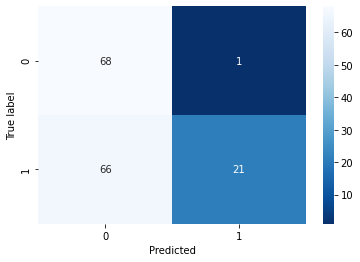

In [152]:
# Построение матрицы ошибок
cm_new = confusion_matrix(y_test, y_pred_threshold)
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('True label')
plt.xlabel('Predicted');


Оформлю выводы: сказав, что нужно сделать дальше, исходя из анализа модели?



Теперь их не 42 а 1. Жаль не 0

Из матрицы ошибок видно следующее:

В 68 случаях модель правильно классифицировала вкусное молоко как 'вкусно'.

В 1 случае модель ошибочно классифицировала невкусное молоко как 'вкусно'

В 66 случаях модель неправильно классифицировала вкусное молоко как 'невкусно'

В 21 случае модель правильно классифицировала невкусное молоко как 'не вкусно'.

(Поздно мной в интернете была найдена таблица, где False Positive перепутан с False Negative. Я надеюсь, что я их не перепутал, потому что я метрил не recall, а precision)

In [153]:
if accuracy <= accuracy_new:
    print('New Accuracy: увеличилась на', (accuracy_new - accuracy))
else:  
    print('New Accuracy: уменьшилась на', (accuracy - accuracy_new))
    
if recall <= recall_new:
    print('New Recall: увеличилась на', (recall_new - recall))
else:  
    print('New Recall: уменьшилась на', (recall - recall_new))

if precision <= precision_new:
    print('New Precision: увеличилась на', (precision_new - precision))
else:  
    print('New Precision: уменьшилась на', (precision - precision_new))

New Accuracy: уменьшилась на 0.05769230769230771
New Recall: уменьшилась на 0.5632183908045977
New Precision: увеличилась на 0.32391482391482396


С помощью обученной модели спрогнозирую вкус молока коров, которых фермер хочет купить.

Выполню подготовку данных, аналогичную той, которую делал для тренировочной выборки.


In [154]:
# Cнова создаем НОВЫЙ датасет
cow_buy_ml_2 = cow_buy.copy(deep=True)


In [155]:
cow_buy_ml_2['эке'] = new_values['эке']
cow_buy_ml_2['эке_2'] = new_values['эке'] ** 2
cow_buy_ml_2['сырой_протеин'] = new_values['сырой_протеин']
cow_buy_ml_2['спо'] = new_values['спо']
cow_buy_ml_2['спо_больше'] = cow_buy_ml_2['спо'].apply(lambda x: 1 if x > 0.91 else 0)

# Форматируем cow_buy
cow_buy_ml_2.rename(columns={'текущая_жирность': 'жирность', 'текущий_белок': 'белок'}, inplace=True)
cow_buy_ml_2 = cow_buy_ml_2.drop(['имя_папы'], axis=1)
cow_buy_ml_2.head()

,порода,тип_пастбища,порода_папы_быка,жирность,белок,возраст,предсказанный_удой,эке,эке_2,сырой_протеин,спо,спо_больше
0,Вис Бик Айдиал,холмистое,Айдиал,3.58,3.076,более_2_лет,6133,15.276742,233.378833,2019.77191,0.958947,1
1,Вис Бик Айдиал,равнинное,Соверин,3.54,3.081,менее_2_лет,6122,15.276742,233.378833,2019.77191,0.958947,1
2,РефлешнСоверинг,равнинное,Соверин,3.59,3.074,более_2_лет,6173,15.276742,233.378833,2019.77191,0.958947,1
3,РефлешнСоверинг,холмистое,Айдиал,3.40,3.061,более_2_лет,6501,15.276742,233.378833,2019.77191,0.958947,1
4,РефлешнСоверинг,равнинное,Айдиал,3.64,3.074,более_2_лет,6501,15.276742,233.378833,2019.77191,0.958947,1


In [156]:
cow_buy_ml_2 = cow_buy_ml_2.drop(['эке', 'спо'], axis=1) #-

In [157]:
cat_col_names = ['порода', 'тип_пастбища', 'порода_папы_быка', 'возраст', 'спо_больше']
num_col_names = ['жирность', 'белок', 'эке_2', 'сырой_протеин']

encoder = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = encoder.fit_transform(X_train_full[cat_col_names])
X_test_ohe = encoder.transform(cow_buy_ml_2[cat_col_names])
encoder_col_names = encoder.get_feature_names()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full[num_col_names])
X_test_scaled = scaler.transform(cow_buy_ml_2[num_col_names])

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train_full = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test_full = pd.concat([X_test_ohe, X_test_scaled], axis=1)

In [158]:
%%time

clf.fit(X_train_full, y_train_full)
y_proba = clf.predict_proba(X_test_full)[:, 1]
predictions_final = (y_proba > OPTIMAL_THRESHOLD).astype(int)

CPU times: user 8.45 ms, sys: 19 µs, total: 8.47 ms
Wall time: 7.07 ms


Получу прогноз вкуса молока коров. В cow_buy уже есть предсказанный_удой

In [159]:
cow_buy['ожидаемый_вкус_молока'] = predictions_final
cow_buy['ожидаемый_вкус_молока'] = cow_buy['ожидаемый_вкус_молока'].apply(lambda x: 'вкусно' if x == 1 else 'не вкусно')
to_buy = cow_buy.query('ожидаемый_вкус_молока == "вкусно"')
cow_buy.loc[(cow_buy['предсказанный_удой'] > 6000) & (cow_buy['ожидаемый_вкус_молока'] == 'вкусно')]

,порода,тип_пастбища,порода_папы_быка,имя_папы,текущая_жирность,текущий_белок,возраст,предсказанный_удой,ожидаемый_вкус_молока
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.4,3.079,менее_2_лет,6501,вкусно


Нашел! Вот она.

предсказанный_удой = 6501 (кг)
ожидаемый_вкус_молока = вкусно

## Итоговые выводы

Добавляю прогнозы вкуса молока и удоя коров «ЭкоФермы» в датафрейм с коровами, покупку которых рассматривает фермер.
В данной задаче ключевым фактором для заказчика был вкус молока и удой коров, который должен составлять не менее 6000 кг в год.
Коротко опишу результаты работы моделей для фермера.
1) Загрузка данных

Исходные файлы с данными были успешно прочитаны. В каждом датафрейме для удобства были изменены названия столбцов.
Количество столбцов в каждом датафрейме соответствует указанному в техническом задании. (мной был добавлен еще один с сахаром)

2) Предобработка данных

Пропуски в данных не были обнаружены. 
В датафреймах были выявлены неявные дубликаты которые были удалены (можно было на медиану заменить, но это ничего бы не дало).
Явные дубликаты также были найдены и устранены.

3) Исследовательский анализ данных

Были выбросы в признаках "удой(кг)" и "жирность(%).

4) Корреляционный анализ признаков в датафрейме ferma_main

Целевой признак "удой":

Наблюдается линейные связи между целевым признаком и входными признаками.

КОЛИЧЕСТВЕННЫЕ ПРИЗНАКИ
 Эке - 0.929525. На диаграмме видно, что есть постепенный прирост удоя в зависимости от увеличения эке. Это утверждение справедливо для всех пород. Наблюдается нелинейная сильная связь.

 Сырой протеин 0.00. Взаимосвязи нет. И на диаграмме слишком большой разброс.
 Спо - 0.909434. Наблюдается нелинейная связь. На графике странная взаимосвязь, которая показывает увеличение удоя в зависимости от роста соотношения сахара и протеина. То есть, между 0.93 и 0.95 есть скачок вверх по удою..
 Жирность - 0.782808. На графике видно, что взаимосвязь проявляется в основном на значениях 3.6 и 3.7. Так как нет промежуточных (более дробных) значений, то явную взаимосвязь трудно разглядеть.
 Белок- 0.650598. Взаимосвязь выше среднего. На графике видно, что порода папы Айдиал выдает более белковосодержащий удой. Да и в целом Айдиал на порядок лучше Соверин. Нелинейна связь.
 Сахар 0.987212. Ситуация абсолютно не аналогична с протеином, сахар имеет гораздо большее влияние на удой, чем сырой протеин. На диаграмме разброс чуть меньше, а взаимосвязь на хетмапе больше. Видимо, сахар влияет на удой, в отличие от протеина. И это влияние более положительное. Однако, я не буду советовать добавлять больше сахара. Не зря существует колонка спо. Скорее всего, содержание сахара в корме не должно превышать содержание сырого протеина. 

КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ
 Порода. 0.502741 Средняя связь есть

Тип пастбища. 0.000000 Нет связи. Не важно, где они пасутся.

Порода папы быка. 0.613422 Вот в этом случае порода сыграла какую то роль, что видно на диаграмме.

Вкус молока. 0.000000 Вкус молока на удой не влияет. 

Возраст. Из категориальных признаков, тут наблюдается самая явная взаимосвязь. Положительная связь (0.995340) у коров, старше 2 лет. Исходя из графика, можно сделать вывод, что молодые коровы приносят меньше удоя, чем те, которые старше 2 лет. Эта взаимосвязь была бы более явной, будь коров старше 2 лет и младше 2 лет поровну.


Результаты работы моделей были добавлены в датафрейм cow_buy, содержащий информацию о продаваемых коровах.
Сколько коров фермер может купить из стада на продажу с минимальным риском для себя?
Вот ВООБЩЕ с минимальным риском он может брать только 1 корову. Для всего остального надо понижать порог, а следовательно увеличивать вероятность ошибки 1-го рода.

Какие ещё рекомендации можно ему дать?

Больше данных. Я бы посоветовал измерять вес, какие лекарства дают корове, чем она болеет и болела ли вообще, что она пьет, есть ли у коровы телята(это тоже влияет). Если при покупке коров будут известны эти данные, то можно получить еще более точные предсказания. (а не то, что получилось у меня, так как в первый раз вообще у всех молоко было не вкусно)

Сделаю выводы о моделях линейной регрессии и логистической регрессии.
Я обучил 3 модели линейной регрессии с остатками и диаграммами остатков.

(В тз было указано четкое использование в моделях тех метрик, которые я не хотел использовать)
Но так или иначе, была получена лучшая из трех моделей

MSE третьей модели: 34225.89491619782

RMSE третьей модели: 185.00241867661575

MAE третьей модели: 146.8912240179252

95% доверительный интервал лучшей модели = (6005.10598068576, 6141.952835460707)

НО Логическая регрессия заняла у меня 90% всего времени работы с проектом.

Узнал какая ошибка критичнее всего при покупке коров:
Это есть ошибка первого рода (ложноположительная) является наиболее критичной при покупке коров.

Как улучшить результаты регрессионной модели?
Я не эксперт, по моему мнению нужно уменьшить число входных признаков, которые имеют слабую корелляцию. И напротив, увеличить количество других признаков? Каких? Тех, которые я посоветовал фермеру выше.

